# Restaurant Revenue Prediction using Linear Regression

## Business Problem

Restaurant revenue varies every day due to several operational factors such as customer count, marketing spend, online orders, weather, and day of the week. This variation makes inventory planning, staff scheduling, and budgeting difficult.

The objective of this project is to build a Machine Learning model that predicts daily restaurant revenue using historical operational data.

## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import cross_val_score

import warnings
warnings.filterwarnings("ignore")

## Load Dataset

In [2]:
df = pd.read_csv(r"/Users/shaguftashaikh/Desktop/restaurant_revenue.csv")

df.head()

,customers,marketing_spend,online_orders,avg_order_value,day_of_week,weather,revenue
0,152,5777.0,102,637.79,Fri,Rainy,38891.94
1,485,4854.0,81,392.44,Thu,Sunny,75271.71
2,398,3491.0,20,394.95,Tue,Sunny,52645.49
3,320,4124.0,114,616.31,Wed,Cloudy,57394.53
4,156,6691.0,23,267.14,Thu,Rainy,20705.51


In [3]:
df.shape

(510, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customers        510 non-null    int64  
 1   marketing_spend  483 non-null    float64
 2   online_orders    510 non-null    int64  
 3   avg_order_value  510 non-null    float64
 4   day_of_week      510 non-null    object 
 5   weather          494 non-null    object 
 6   revenue          510 non-null    float64
dtypes: float64(3), int64(2), object(2)
memory usage: 28.0+ KB


In [5]:
df.describe()

,customers,marketing_spend,online_orders,avg_order_value,revenue
count,510.000000,483.000000,510.000000,510.000000,5.100000e+02
mean,277.705882,5607.122153,103.290196,458.854667,5.222997e+04
std,126.379009,2534.174161,55.469828,205.295073,4.877583e+04
min,51.000000,1004.000000,10.000000,103.460000,7.767720e+03
25%,177.000000,3521.500000,51.250000,271.072500,3.682416e+04
50%,277.500000,5777.000000,106.000000,468.045000,5.049729e+04
75%,389.000000,7826.000000,153.000000,637.197500,6.276737e+04
max,499.000000,9989.000000,199.000000,799.590000,1.041253e+06


## Data Quality Check

In [6]:
## Handling Missing Values
df.isnull().sum()

customers           0
marketing_spend    27
online_orders       0
avg_order_value     0
day_of_week         0
weather            16
revenue             0
dtype: int64

In [7]:
# Fill numerical missing values
df["marketing_spend"].fillna(df["marketing_spend"].median(), inplace=True)

# Fill categorical missing values
df["weather"].fillna(df["weather"].mode()[0], inplace=True)

In [8]:
df.isnull().sum()

customers          0
marketing_spend    0
online_orders      0
avg_order_value    0
day_of_week        0
weather            0
revenue            0
dtype: int64

## Removing Duplicate Records

In [9]:
df.duplicated().sum()

np.int64(10)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

## Detecting Outliers

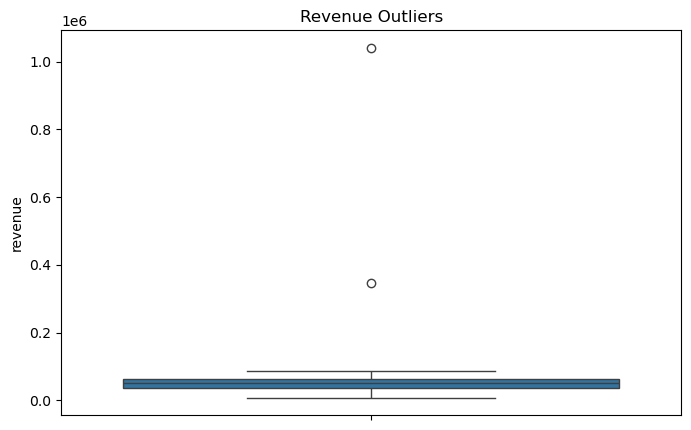

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df["revenue"])
plt.title("Revenue Outliers")
plt.show()

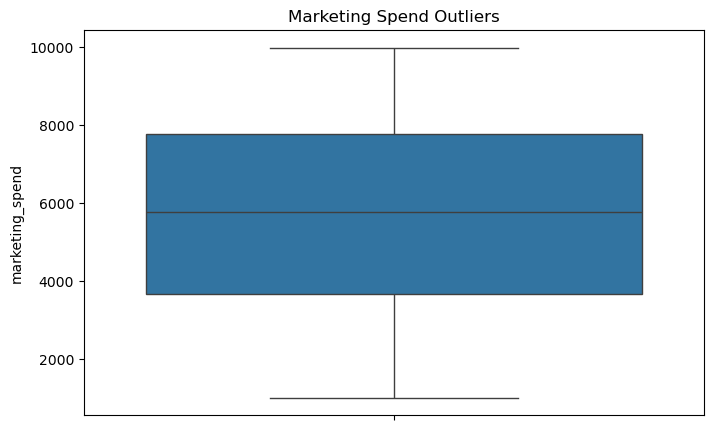

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df["marketing_spend"])
plt.title("Marketing Spend Outliers")
plt.show()

## Exploratory Data Analysis

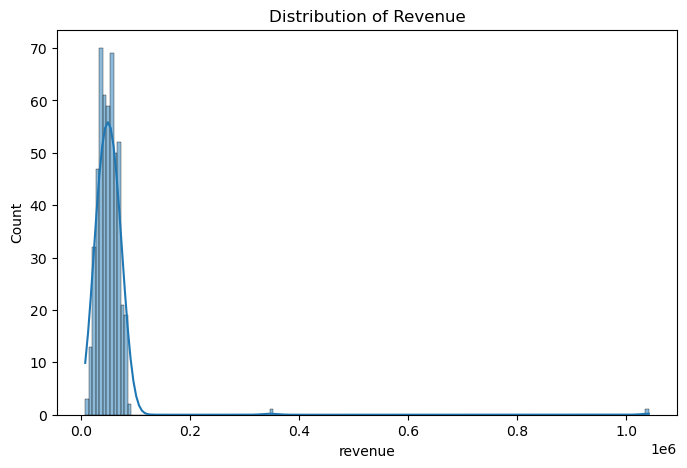

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df["revenue"], kde=True)
plt.title("Distribution of Revenue")
plt.show()

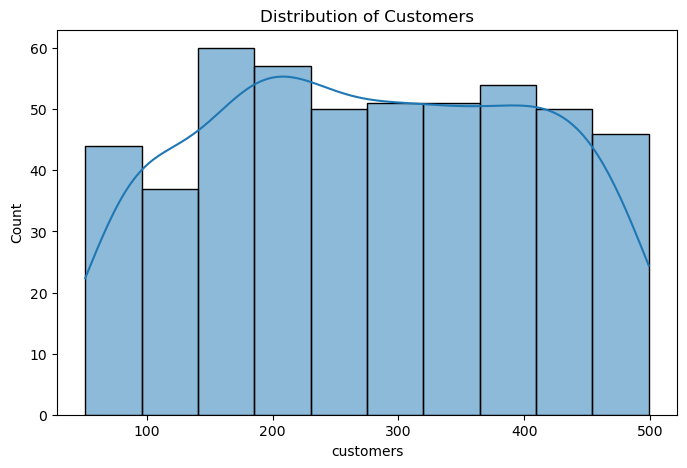

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df["customers"], kde=True)
plt.title("Distribution of Customers")
plt.show()

In [16]:
df_eda = df.copy()

le = LabelEncoder()

df_eda["day_of_week"] = le.fit_transform(df_eda["day_of_week"])
df_eda["weather"] = le.fit_transform(df_eda["weather"])

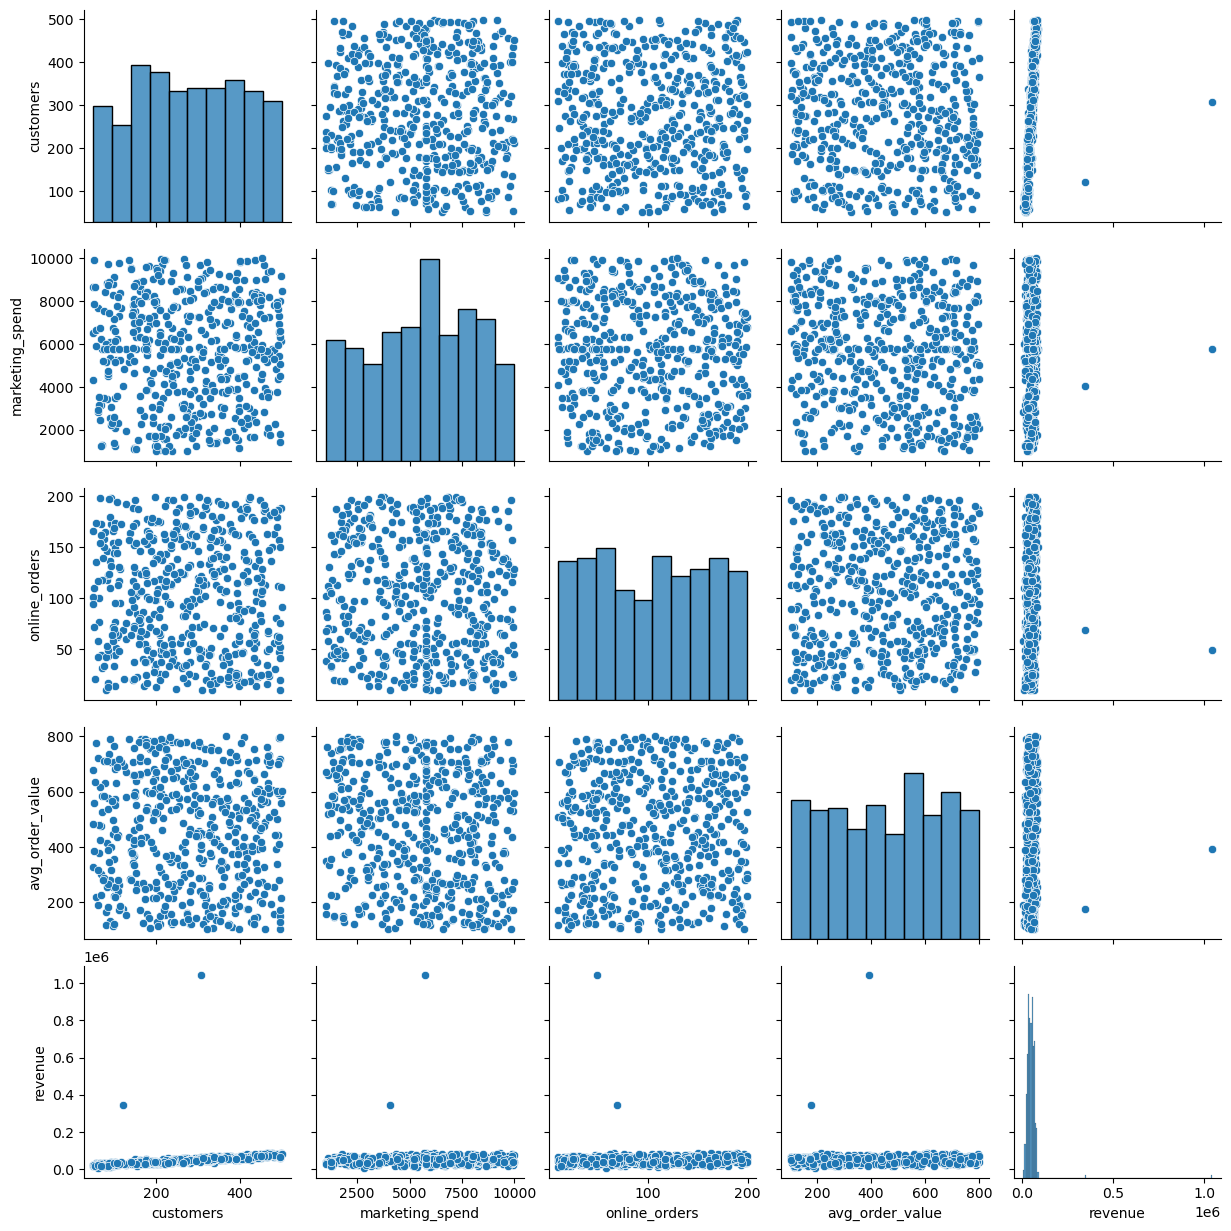

In [17]:
sns.pairplot(
    df[["customers",
        "marketing_spend",
        "online_orders",
        "avg_order_value",
        "revenue"]]
)
plt.show()

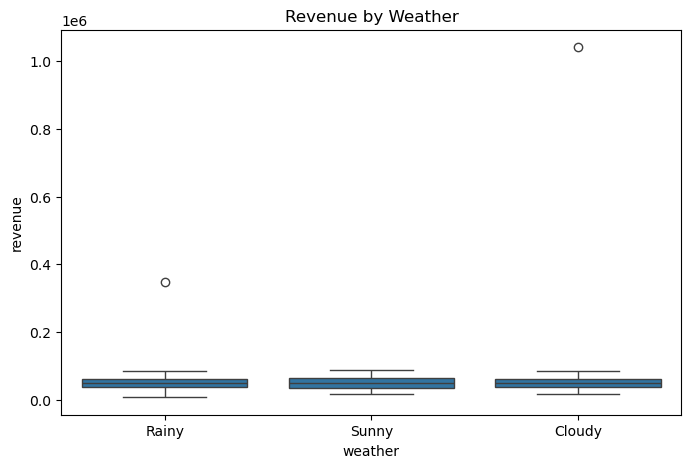

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x="weather", y="revenue", data=df)
plt.title("Revenue by Weather")
plt.show()

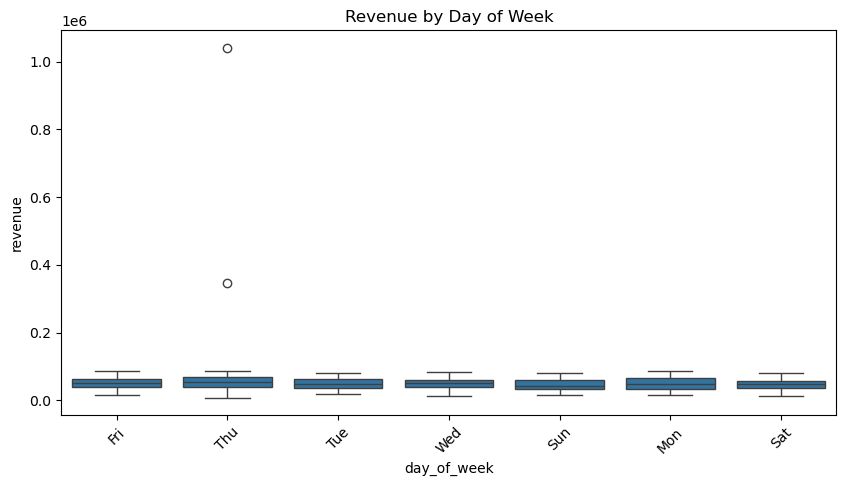

In [19]:
plt.figure(figsize=(10,5))
sns.boxplot(x="day_of_week", y="revenue", data=df)
plt.xticks(rotation=45)
plt.title("Revenue by Day of Week")
plt.show()

### Observations

- Revenue is influenced mainly by customer count and average order value.
- Marketing spend shows a moderate positive relationship with revenue.
- Online orders also contribute positively to revenue.
- Revenue varies across different weather conditions and days of the week.
- No severe multicollinearity is visible from the correlation heatmap.

## Feature Engineering and Encoding

In [20]:
df["day_of_week"].unique()

array(['Fri', 'Thu', 'Tue', 'Wed', 'Sun', 'Mon', 'Sat'], dtype=object)

In [21]:
df["weather"].unique()

array(['Rainy', 'Sunny', 'Cloudy'], dtype=object)

In [22]:
day_mapping = {
    "Mon": 1,
    "Tue": 2,
    "Wed": 3,
    "Thu": 4,
    "Fri": 5,
    "Sat": 6,
    "Sun": 7
}

df["day_of_week"] = df["day_of_week"].map(day_mapping)

In [23]:
df.head()

,customers,marketing_spend,online_orders,avg_order_value,day_of_week,weather,revenue
0,152,5777.0,102,637.79,5,Rainy,38891.94
1,485,4854.0,81,392.44,4,Sunny,75271.71
2,398,3491.0,20,394.95,2,Sunny,52645.49
3,320,4124.0,114,616.31,3,Cloudy,57394.53
4,156,6691.0,23,267.14,4,Rainy,20705.51


In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["weather"] = le.fit_transform(df["weather"])

## Checking Multicollinearity using Variance Inflation Factor (VIF)

In [25]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [26]:
X = df.drop("revenue", axis=1)

In [27]:
vif = pd.DataFrame()

vif["Feature"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif

,Feature,VIF
0,customers,4.657702
1,marketing_spend,4.883161
2,online_orders,3.992991
3,avg_order_value,4.471431
4,day_of_week,4.186757
5,weather,2.446764


### Observation

All VIF values are within the acceptable range. Therefore, no significant multicollinearity exists among the independent variables, and all features are retained for model training.

## Train-Test Split and Feature Scaling

In [28]:
X = df.drop("revenue", axis=1)
y = df["revenue"]

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [31]:
print("Training Features :", X_train_scaled.shape)
print("Testing Features  :", X_test_scaled.shape)
print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (400, 6)
Testing Features  : (100, 6)
Training Target   : (400,)
Testing Target    : (100,)


## Model Building using Linear Regression

In [32]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled, y_train)

LinearRegression()

In [33]:
y_pred = model.predict(X_test_scaled)

## Model Evaluation

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R² Score :", r2)

MAE : 6191.997056035054
MSE : 57529292.408422574
RMSE : 7584.806682336905
R² Score : 0.7868838305537624


## 5-Fold Cross Validation

In [35]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage R² Score:", cv_scores.mean())

Cross Validation Scores:
[-0.01077979  0.80056318  0.75761743  0.79491826  0.77131953]

Average R² Score: 0.6227277214708913


## Model Coefficients

In [36]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
0,customers,14838.700177
1,marketing_spend,1393.275038
3,avg_order_value,1161.475493
2,online_orders,401.930277
4,day_of_week,-337.122370
5,weather,-2759.948307


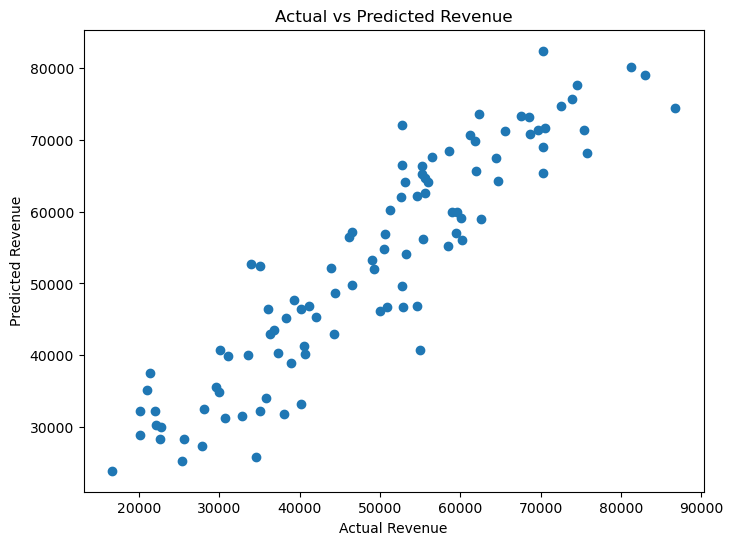

In [37]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted Revenue")
plt.show()

# Conclusion

A Linear Regression model was developed to predict restaurant revenue based on operational features such as customer count, marketing spend, online orders, average order value, day of the week, and weather.

The model was evaluated using MAE, MSE, RMSE, and R² score. Cross-validation was performed to validate the model's generalization capability. The results indicate that the model can effectively forecast daily restaurant revenue, helping restaurant management improve inventory planning, staff scheduling, and marketing decisions.